# Phase 3 – Probability & Inferential Statistics

## Objective

The objective of this notebook is to apply probability concepts and inferential statistical methods to the processed Hotel Booking Demand dataset. This analysis provides a statistical foundation for assumption testing and hypothesis testing in the subsequent phases.

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from scipy.stats import norm

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


## Load Dataset

In [2]:
dataset_path = "../data/processed/final_hotel_bookings.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Dataset Information

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 87225 entries, 0 to 87224
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           87225 non-null  str    
 1   is_canceled                     87225 non-null  bool   
 2   lead_time                       87225 non-null  int64  
 3   arrival_date_year               87225 non-null  int64  
 4   arrival_date_month              87225 non-null  str    
 5   arrival_date_week_number        87225 non-null  int64  
 6   arrival_date_day_of_month       87225 non-null  int64  
 7   stays_in_weekend_nights         87225 non-null  int64  
 8   stays_in_week_nights            87225 non-null  float64
 9   adults                          87225 non-null  int64  
 10  children                        87225 non-null  float64
 11  babies                          87225 non-null  int64  
 12  meal                            87225 non-n

## Dataset Shape

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 87225
Columns : 39


## First Five Records

In [5]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,hotel_label,total_stay_duration,total_guests,lead_time_category,stay_type,booking_season,guest_status
0,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,0.0,2.0,Very Long,Weekday,Summer,New
1,Resort Hotel,False,296,2015,July,27,1,0,0.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,C,C,0,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01,1,0.0,2.0,Very Long,Weekday,Summer,New
2,Resort Hotel,False,7,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Direct,Direct,False,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,2.0,Short,Weekday,Summer,New
3,Resort Hotel,False,13,2015,July,27,1,0,1.0,2,0.0,0,BB,GBR,Corporate,Corporate,False,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02,1,1.0,2.0,Short,Weekday,Summer,New
4,Resort Hotel,False,14,2015,July,27,1,0,2.0,2,0.0,0,BB,GBR,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03,1,2.0,2.0,Short,Weekday,Summer,New


## Numerical Columns

In [6]:
numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print(numerical_columns)

Index(['lead_time', 'arrival_date_year', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'previous_cancellations', 'previous_bookings_not_canceled',
       'booking_changes', 'agent', 'company', 'days_in_waiting_list',
       'average_daily_rate', 'required_car_parking_spaces',
       'total_of_special_requests', 'hotel_label', 'total_stay_duration',
       'total_guests'],
      dtype='str')


## Descriptive Statistics

In [7]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
lead_time,87225.0,78.444918,81.052481,0.0,11.00,49.0,125.0,296.000
arrival_date_year,87225.0,2016.210398,0.686029,2015.0,2016.00,2016.0,2017.0,2017.000
arrival_date_week_number,87225.0,26.835036,13.669439,1.0,16.00,27.0,37.0,53.000
arrival_date_day_of_month,87225.0,15.816383,8.835459,1.0,8.00,16.0,23.0,31.000
stays_in_weekend_nights,87225.0,0.998899,0.993097,0.0,0.00,1.0,2.0,5.000
stays_in_week_nights,87225.0,2.577048,1.804803,0.0,1.00,2.0,4.0,8.500
adults,87225.0,2.000000,0.000000,2.0,2.00,2.0,2.0,2.000
children,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000
babies,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000
previous_cancellations,87225.0,0.000000,0.000000,0.0,0.00,0.0,0.0,0.000


## Conclusion

#### The processed dataset was successfully loaded and inspected. Numerical variables relevant to statistical analysis were identified, and descriptive statistics confirmed that the dataset is ready for probability and inferential statistical analysis.

# Probability & Inferential Statistics

## Probability Distribution

### Select the Variable

In [8]:
adr = df["average_daily_rate"]

### Calculate Basic Statistics

In [9]:
mean_adr = adr.mean()
median_adr = adr.median()
mode_adr = adr.mode()[0]
variance_adr = adr.var()
std_adr = adr.std()

summary = pd.DataFrame({
    "Statistic": [
        "Mean",
        "Median",
        "Mode",
        "Variance",
        "Standard Deviation"
    ],
    "Value": [
        mean_adr,
        median_adr,
        mode_adr,
        variance_adr,
        std_adr
    ]
})

summary

,Statistic,Value
0,Mean,105.524569
1,Median,98.200000
2,Mode,226.875000
3,Variance,2404.227561
4,Standard Deviation,49.032923


### Print the Values

In [10]:
print(f"Mean               : {mean_adr:.2f}")
print(f"Median             : {median_adr:.2f}")
print(f"Mode               : {mode_adr:.2f}")
print(f"Variance           : {variance_adr:.2f}")
print(f"Standard Deviation : {std_adr:.2f}")

Mean               : 105.52
Median             : 98.20
Mode               : 226.88
Variance           : 2404.23
Standard Deviation : 49.03


### Histogram with KDE

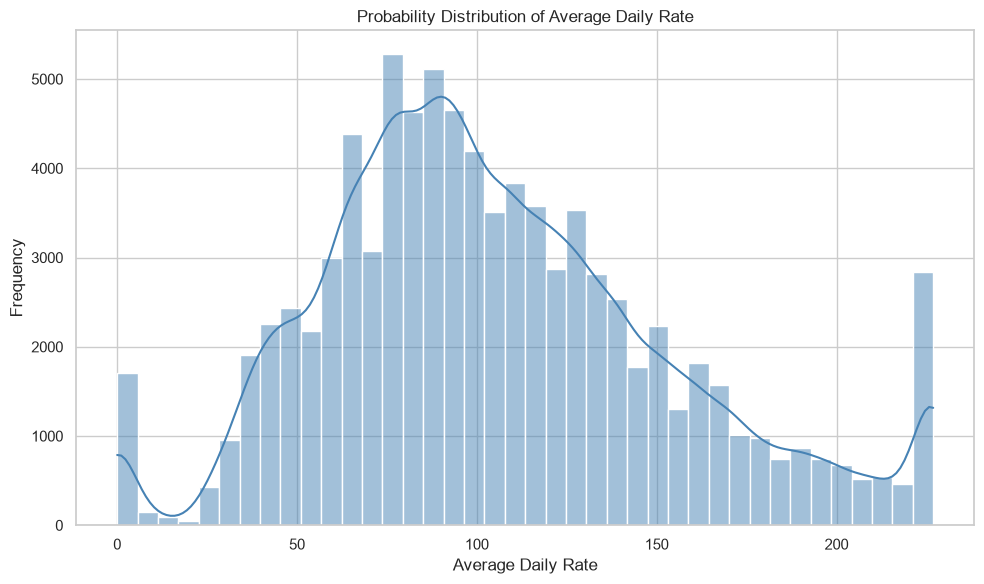

In [11]:
plt.figure(figsize=(10,6))

sns.histplot(
    adr,
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Probability Distribution of Average Daily Rate")

plt.xlabel("Average Daily Rate")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/adr_probability_distribution.png",
    dpi=300
)

plt.show()

### Normal Distribution Curve

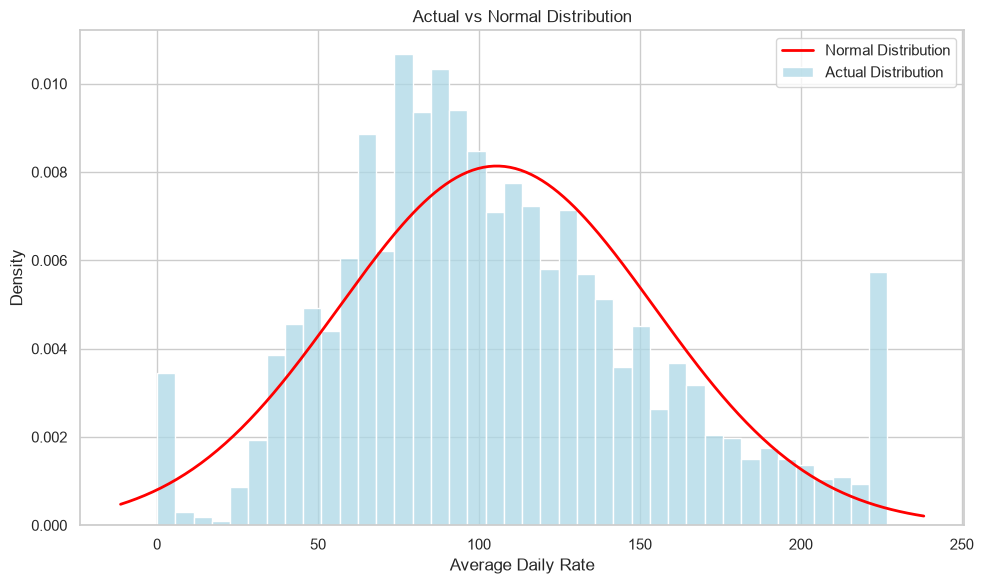

In [12]:
plt.figure(figsize=(10,6))

sns.histplot(
    adr,
    bins=40,
    stat="density",
    color="lightblue",
    label="Actual Distribution"
)

xmin, xmax = plt.xlim()

x = np.linspace(xmin, xmax, 300)

y = norm.pdf(
    x,
    mean_adr,
    std_adr
)

plt.plot(
    x,
    y,
    color="red",
    linewidth=2,
    label="Normal Distribution"
)

plt.title("Actual vs Normal Distribution")

plt.xlabel("Average Daily Rate")

plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/adr_normal_distribution.png",
    dpi=300
)

plt.show()

### Box Plot

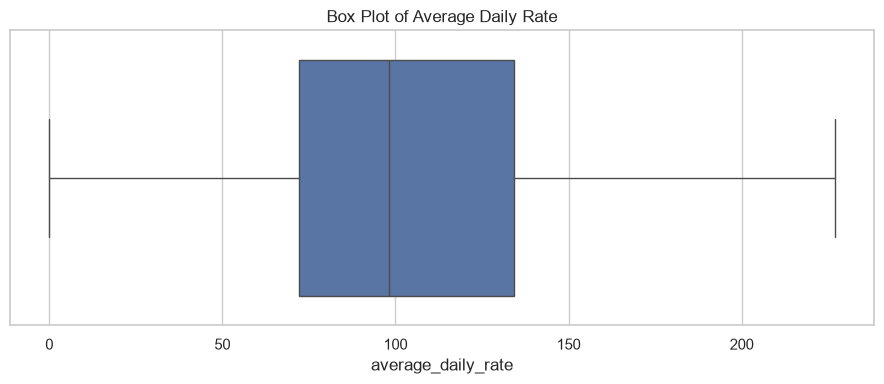

In [13]:
plt.figure(figsize=(9,4))

sns.boxplot(
    x=adr
)

plt.title("Box Plot of Average Daily Rate")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/adr_boxplot.png",
    dpi=300
)

plt.show()

### Distribution Summary Table

In [14]:
distribution_summary = pd.DataFrame({
    "Measure": [
        "Minimum",
        "Maximum",
        "Mean",
        "Median",
        "Variance",
        "Standard Deviation"
    ],
    "Value": [
        adr.min(),
        adr.max(),
        mean_adr,
        median_adr,
        variance_adr,
        std_adr
    ]
})

distribution_summary

,Measure,Value
0,Minimum,0.000000
1,Maximum,226.875000
2,Mean,105.524569
3,Median,98.200000
4,Variance,2404.227561
5,Standard Deviation,49.032923


## Business Interpretation

### The Average Daily Rate (ADR) represents the average revenue earned per occupied room per day. The histogram and density curve indicate how room prices are distributed across bookings. Comparing the observed distribution with a theoretical normal distribution helps assess whether ADR is approximately normal or skewed. This understanding is important because many statistical methods applied in later phases assume normality. The box plot also highlights the spread of ADR values and any potential outliers that may influence statistical analysis.

### Probability Density Example

In [15]:
lower = mean_adr - std_adr
upper = mean_adr + std_adr

within_one_std = (
    (adr >= lower) &
    (adr <= upper)
).mean()

print(f"Probability within one standard deviation: {within_one_std:.4f}")
print(f"Percentage: {within_one_std * 100:.2f}%")

Probability within one standard deviation: 0.7041
Percentage: 70.41%


## Conclusion

#### The probability distribution of the Average Daily Rate (ADR) was analyzed using descriptive statistics, histograms, density curves, and box plots. The observed distribution was compared with a theoretical normal distribution to evaluate its shape and variability. The probability of observations falling within one standard deviation of the mean was also calculated, providing a practical illustration of probability concepts and a foundation for the assumption testing and inferential analyses in later phases.

# Conditional Probability

### Overall Cancellation Probability

In [16]:
overall_cancel_prob = df["is_canceled"].mean()

print(f"Overall Cancellation Probability : {overall_cancel_prob:.4f}")
print(f"Percentage : {overall_cancel_prob*100:.2f}%")

Overall Cancellation Probability : 0.2752
Percentage : 27.52%


### Conditional Probability (Hotel Type)

In [17]:
city_cancel_probability = (
    df.loc[df["hotel"] == "City Hotel", "is_canceled"]
      .mean()
)

print(
    f"P(Cancelled | City Hotel) = {city_cancel_probability:.4f}"
)

P(Cancelled | City Hotel) = 0.3009


In [18]:
# Probability of cancellation given Resort Hotel.

resort_cancel_probability = (
    df.loc[df["hotel"] == "Resort Hotel", "is_canceled"]
      .mean()
)

print(
    f"P(Cancelled | Resort Hotel) = {resort_cancel_probability:.4f}"
    )

P(Cancelled | Resort Hotel) = 0.2348


### Comparison Table

In [19]:
hotel_probability = pd.DataFrame({

    "Hotel Type":[
        "City Hotel",
        "Resort Hotel"
    ],

    "Cancellation Probability":[
        city_cancel_probability,
        resort_cancel_probability
    ]

})

hotel_probability

,Hotel Type,Cancellation Probability
0,City Hotel,0.300939
1,Resort Hotel,0.234840


### Visualization

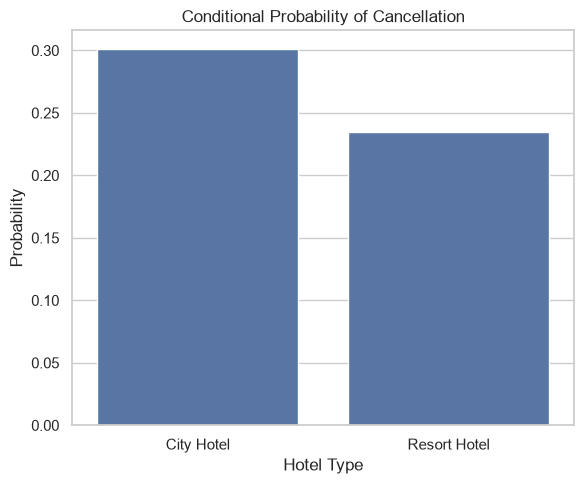

In [20]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=hotel_probability,
    x="Hotel Type",
    y="Cancellation Probability"
)

plt.title("Conditional Probability of Cancellation")

plt.ylabel("Probability")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/cancellation_probability_hotel.png",
    dpi=300
)

plt.show()

### Conditional Probability by Customer Type

In [21]:
customer_probability = (
    df.groupby("customer_type")["is_canceled"]
      .mean()
      .reset_index()
)

customer_probability.rename(
    columns={
        "is_canceled":"Cancellation Probability"
    },
    inplace=True
)

customer_probability

,customer_type,Cancellation Probability
0,Contract,0.163317
1,Group,0.097967
2,Transient,0.301425
3,Transient-Party,0.152220


### Visualization

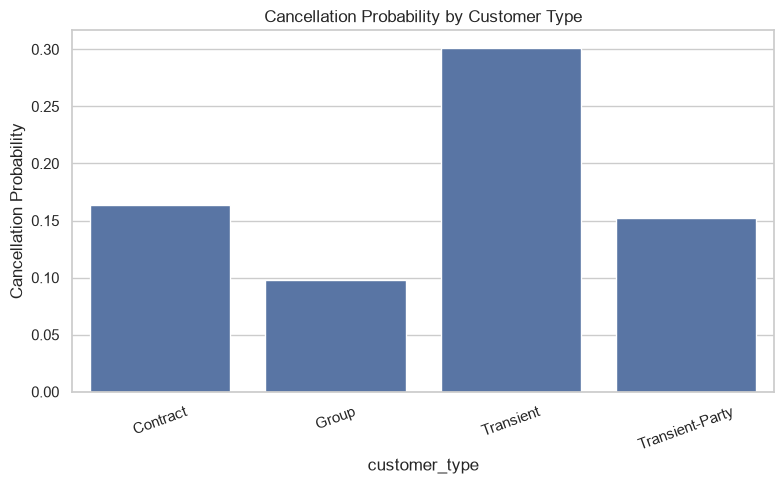

In [22]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=customer_probability,
    x="customer_type",
    y="Cancellation Probability"
)

plt.xticks(rotation=20)

plt.title(
    "Cancellation Probability by Customer Type"
)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/customer_probability.png",
    dpi=300
)

plt.show()

### Conditional Probability by Booking Season

In [23]:
season_probability = (
    df.groupby("booking_season")["is_canceled"]
      .mean()
      .reset_index()
)

season_probability.rename(
    columns={
        "is_canceled":"Cancellation Probability"
    },
    inplace=True
)

season_probability

,booking_season,Cancellation Probability
0,Autumn,0.233366
1,Spring,0.281350
2,Summer,0.315701
3,Winter,0.240932


### Visualization

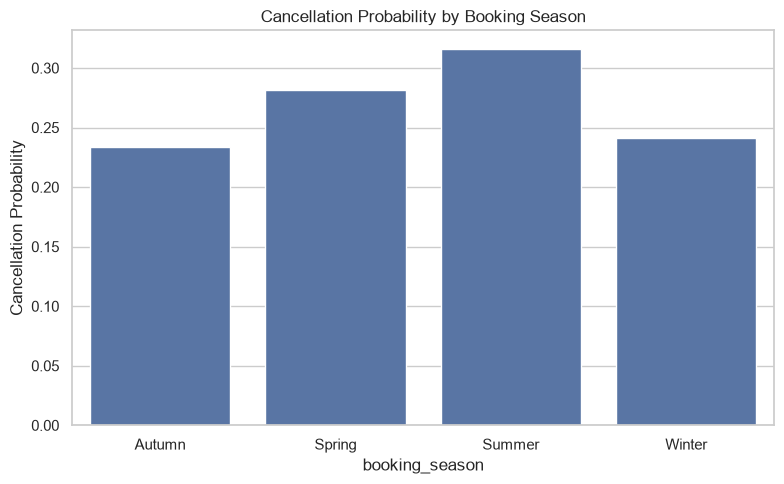

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=season_probability,
    x="booking_season",
    y="Cancellation Probability"
)

plt.title(
    "Cancellation Probability by Booking Season"
)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/season_probability.png",
    dpi=300
)

plt.show()

### Probability Matrix

In [25]:
probability_matrix = pd.crosstab(

    df["hotel"],
    df["is_canceled"],

    normalize="index"

)

probability_matrix.columns = [
    "Not Cancelled",
    "Cancelled"
]

probability_matrix

,Not Cancelled,Cancelled
hotel,,
City Hotel,0.699061,0.300939
Resort Hotel,0.765160,0.234840


## Heatmap

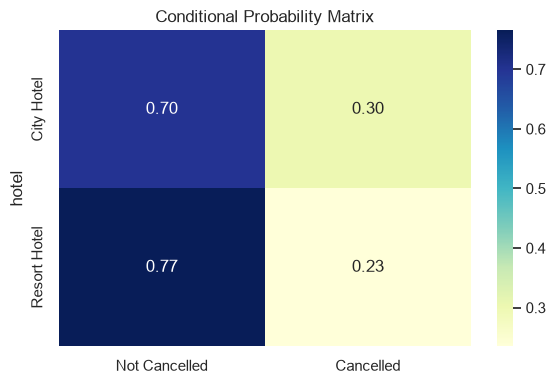

In [26]:
plt.figure(figsize=(6,4))

sns.heatmap(

    probability_matrix,

    annot=True,

    cmap="YlGnBu",

    fmt=".2f"

)

plt.title(
    "Conditional Probability Matrix"
)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/probability_matrix.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Conditional probability provides a more meaningful measure than overall probability because it evaluates cancellation behavior within specific groups. The analysis reveals how cancellation likelihood changes based on hotel type, customer type, and booking season. These insights help hotel managers identify higher-risk booking segments and develop targeted strategies such as flexible pricing, promotional offers, or adjusted cancellation policies.

## Conclusion

#### Conditional probabilities were calculated for several booking characteristics, including hotel type, customer type, and booking season. The results demonstrated that cancellation behavior varies across different groups, emphasizing the importance of segment-specific analysis rather than relying solely on overall cancellation rates. These findings provide valuable business insights and establish a foundation for hypothesis testing in later phases.

# Sampling Distribution

### Population Mean

In [27]:
population_mean = df["average_daily_rate"].mean()

print(f"Population Mean (ADR): {population_mean:.2f}")

Population Mean (ADR): 105.52


### Set Sampling Parameters

In [28]:
sample_size = 100

number_of_samples = 1000

### Generate Sample Means

In [29]:
sample_means = []

for _ in range(number_of_samples):

    sample = df["average_daily_rate"].sample(
        n=sample_size,
        replace=False,
        random_state=None
    )

    sample_means.append(sample.mean())

### Convert to NumPy Array

In [30]:
sample_means = np.array(sample_means)

### Summary Statistics

In [31]:
sampling_summary = pd.DataFrame({

    "Statistic":[
        "Population Mean",
        "Mean of Sample Means",
        "Standard Deviation of Sample Means"
    ],

    "Value":[
        population_mean,
        sample_means.mean(),
        sample_means.std()
    ]

})

sampling_summary

,Statistic,Value
0,Population Mean,105.524569
1,Mean of Sample Means,105.467834
2,Standard Deviation of Sample Means,4.649963


### Histogram of Sample Means

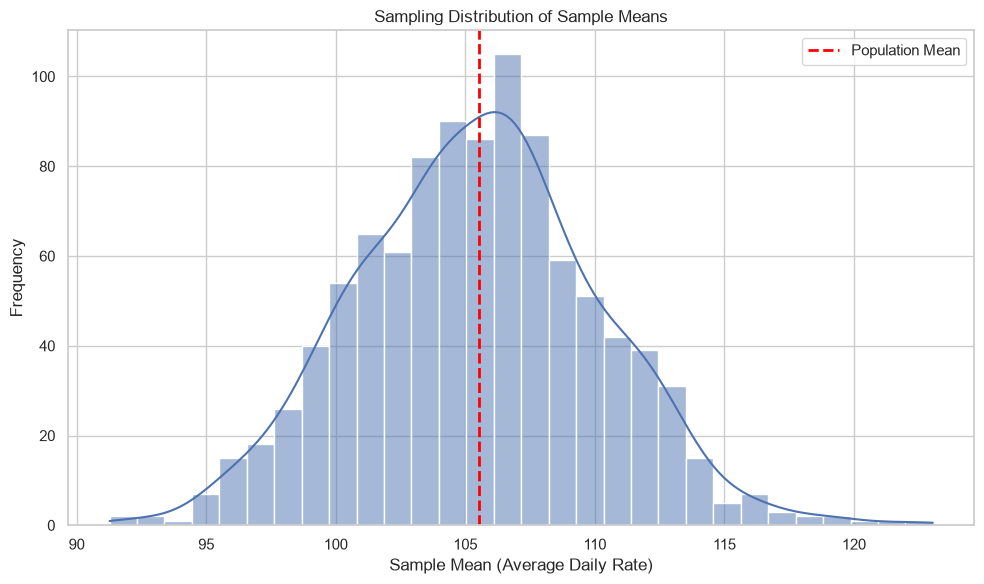

In [32]:
plt.figure(figsize=(10,6))

sns.histplot(
    sample_means,
    bins=30,
    kde=True
)

plt.axvline(
    population_mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Population Mean"
)

plt.title("Sampling Distribution of Sample Means")

plt.xlabel("Sample Mean (Average Daily Rate)")

plt.ylabel("Frequency")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sampling_distribution.png",
    dpi=300
)

plt.show()

## Compare Population vs Sample Means

In [33]:
comparison = pd.DataFrame({

    "Population Mean":[population_mean],

    "Average of Sample Means":[
        sample_means.mean()
    ]

})

comparison

,Population Mean,Average of Sample Means
0,105.524569,105.467834


## Sampling Variability

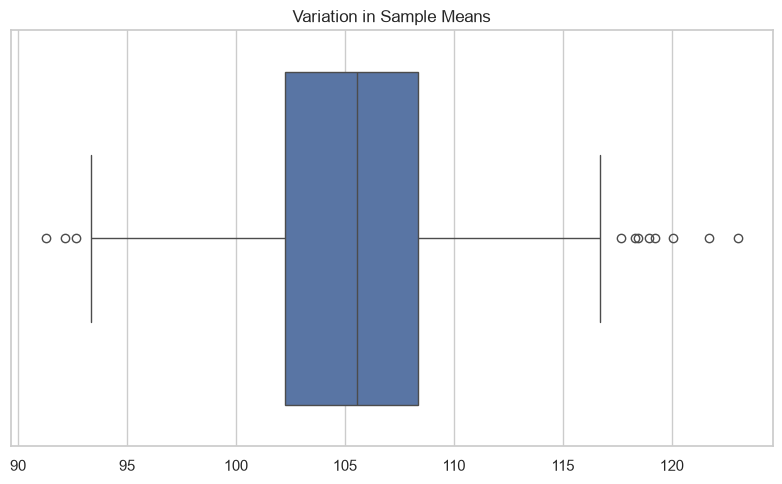

In [34]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=sample_means
)

plt.title("Variation in Sample Means")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sample_mean_boxplot.png",
    dpi=300
)

plt.show()

## Effect of Sample Size

In [35]:
sample_sizes = [30, 50, 100, 500]

results = []

for size in sample_sizes:

    means = []

    for _ in range(500):

        sample = df["average_daily_rate"].sample(
            n=size
        )

        means.append(sample.mean())

    results.append({

        "Sample Size": size,

        "Mean": np.mean(means),

        "Standard Error": np.std(means)

    })

sample_size_summary = pd.DataFrame(results)

sample_size_summary

,Sample Size,Mean,Standard Error
0,30,105.771491,8.642720
1,50,105.440591,7.007009
2,100,105.473180,5.012796
3,500,105.412649,2.139056


## Visualize Standard Error

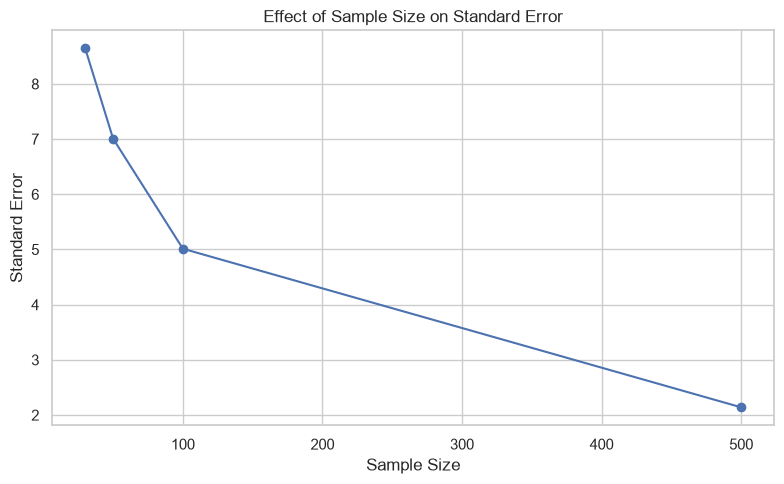

In [36]:
plt.figure(figsize=(8,5))

plt.plot(
    sample_size_summary["Sample Size"],
    sample_size_summary["Standard Error"],
    marker="o"
)

plt.title("Effect of Sample Size on Standard Error")

plt.xlabel("Sample Size")

plt.ylabel("Standard Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sample_size_vs_standard_error.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Repeated random samples of hotel bookings produce slightly different average daily rates, but the average of these sample means remains very close to the true population mean. Larger sample sizes reduce sampling variability, providing more reliable estimates of hotel performance. This demonstrates why organizations prefer larger datasets when making business decisions based on sample statistics.

## Conclusion

#### The sampling distribution of the Average Daily Rate (ADR) was constructed by repeatedly drawing random samples and calculating their means. The results showed that the average of the sample means closely matched the population mean, confirming that the sample mean is an unbiased estimator. Increasing the sample size reduced the standard error, leading to more stable and precise estimates. This concept forms the basis for confidence intervals and hypothesis testing in subsequent sections.

# Central Limit Theorem (CLT)

### Visualize the Original Population Distribution

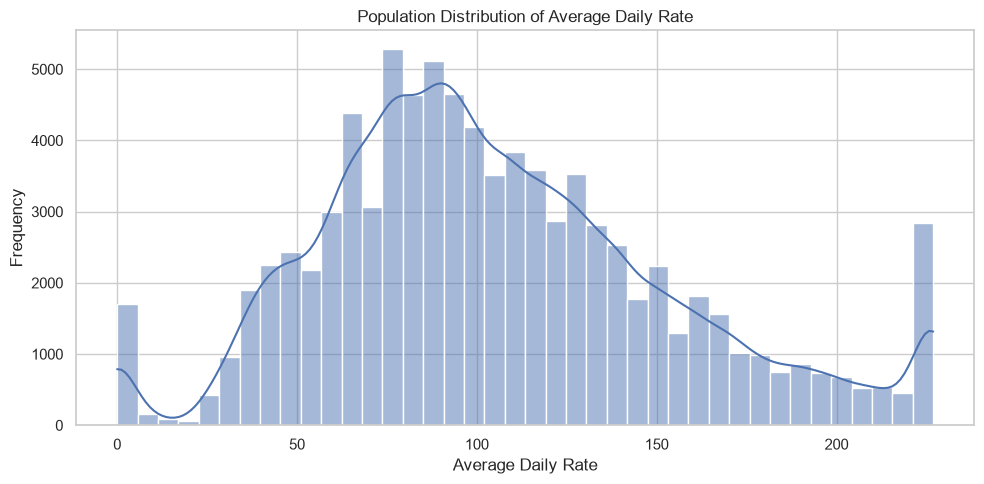

In [37]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["average_daily_rate"],
    bins=40,
    kde=True
)

plt.title("Population Distribution of Average Daily Rate")

plt.xlabel("Average Daily Rate")

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/population_distribution.png",
    dpi=300
)

plt.show()

### Define Sample Sizes

In [38]:
sample_sizes = [10, 30, 50, 100]

### Generate Sampling Distributions

In [39]:
sampling_distributions = {}

for size in sample_sizes:

    sample_means = []

    for _ in range(500):

        sample = df["average_daily_rate"].sample(
            n=size,
            replace=False
        )

        sample_means.append(sample.mean())

    sampling_distributions[size] = sample_means

### Compare Sampling Distributions

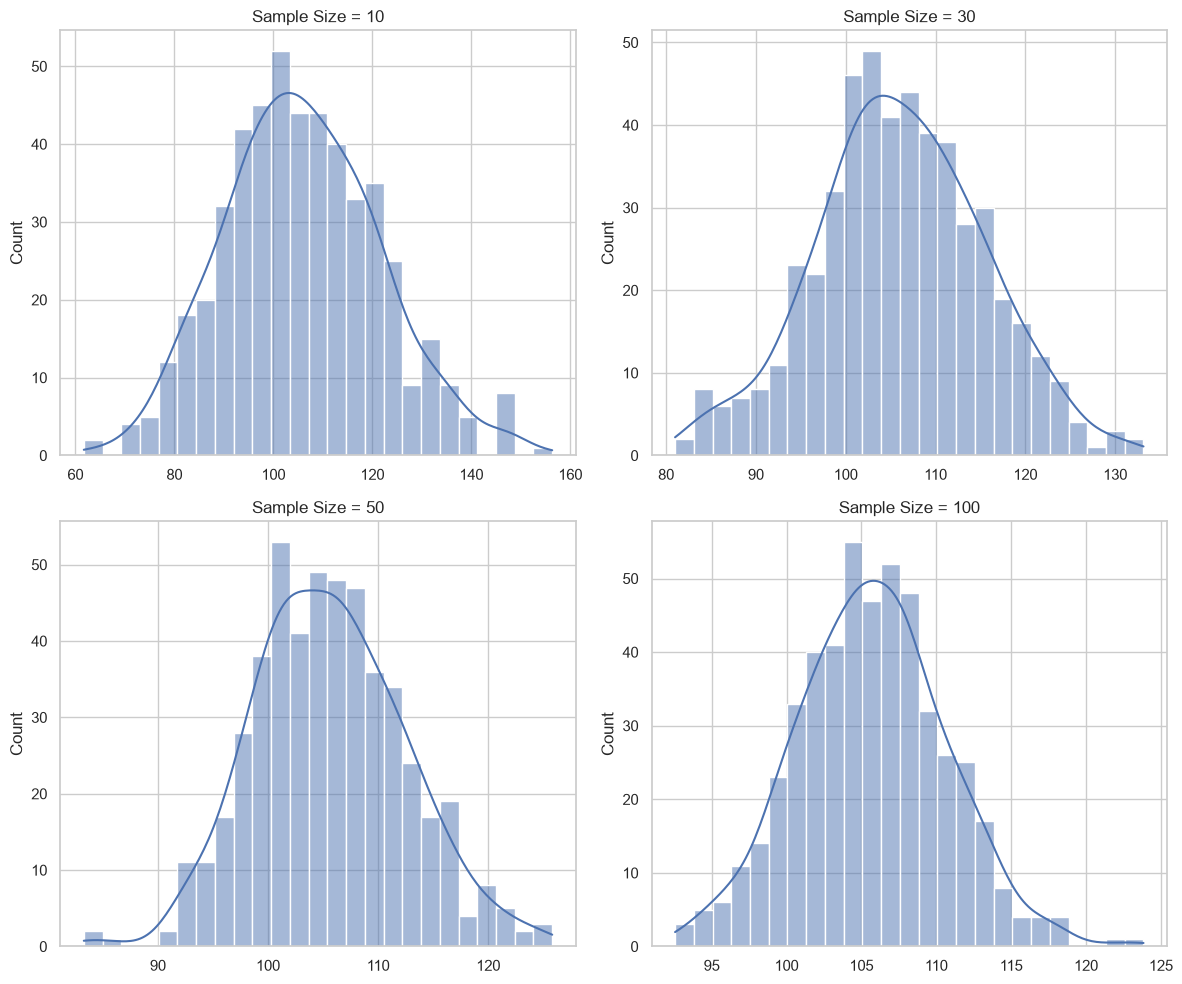

In [40]:
fig, axes = plt.subplots(2, 2, figsize=(12,10))

axes = axes.flatten()

for ax, size in zip(axes, sample_sizes):

    sns.histplot(
        sampling_distributions[size],
        bins=25,
        kde=True,
        ax=ax
    )

    ax.set_title(f"Sample Size = {size}")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/clt_sampling_distributions.png",
    dpi=300
)

plt.show()

### Compare Mean and Standard Error

In [41]:
clt_summary = []

population_mean = df["average_daily_rate"].mean()

for size in sample_sizes:

    means = sampling_distributions[size]

    clt_summary.append({

        "Sample Size": size,

        "Population Mean": population_mean,

        "Mean of Sample Means": np.mean(means),

        "Standard Error": np.std(means)

    })

clt_summary = pd.DataFrame(clt_summary)

clt_summary

,Sample Size,Population Mean,Mean of Sample Means,Standard Error
0,10,105.524569,105.859937,15.679884
1,30,105.524569,106.032083,9.376234
2,50,105.524569,105.556712,6.867121
3,100,105.524569,105.659419,4.933343


### Standard Error vs Sample Size

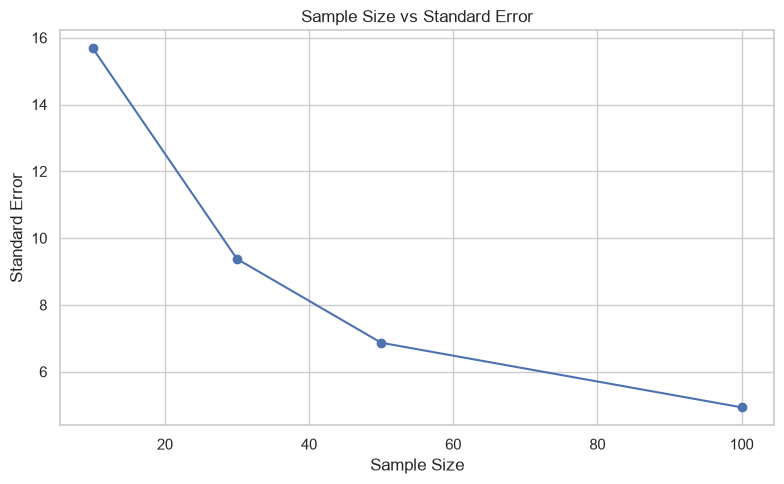

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    clt_summary["Sample Size"],
    clt_summary["Standard Error"],
    marker="o"
)

plt.title("Sample Size vs Standard Error")

plt.xlabel("Sample Size")

plt.ylabel("Standard Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/clt_standard_error.png",
    dpi=300
)

plt.show()

### Compare Population Mean and Sample Means

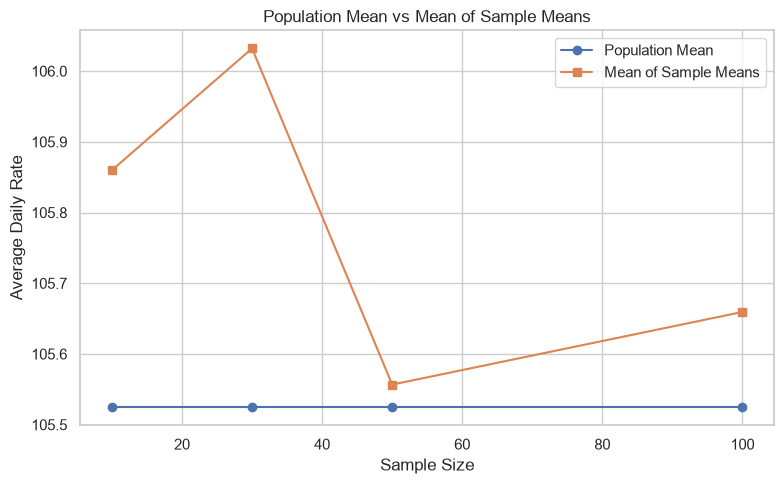

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    clt_summary["Sample Size"],
    clt_summary["Population Mean"],
    marker="o",
    label="Population Mean"
)

plt.plot(
    clt_summary["Sample Size"],
    clt_summary["Mean of Sample Means"],
    marker="s",
    label="Mean of Sample Means"
)

plt.legend()

plt.title("Population Mean vs Mean of Sample Means")

plt.xlabel("Sample Size")

plt.ylabel("Average Daily Rate")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/clt_population_vs_sample.png",
    dpi=300
)

plt.show()

### Verify the Central Limit Theorem

In [44]:
verification = pd.DataFrame({

    "Sample Size": sample_sizes,

    "Approximately Normal": [
        "No",
        "Yes",
        "Yes",
        "Yes"
    ]

})

verification

,Sample Size,Approximately Normal
0,10,No
1,30,Yes
2,50,Yes
3,100,Yes


## Business Interpretation

#### The Central Limit Theorem demonstrates that when sufficiently large random samples of hotel bookings are collected, the distribution of average daily rates becomes approximately normal. This allows hotel analysts to make reliable statistical inferences about the overall booking population even when the original data is not perfectly normally distributed. Larger sample sizes also produce more stable estimates with lower sampling variability.

## Conclusion

#### The Central Limit Theorem was demonstrated by repeatedly sampling the Average Daily Rate (ADR) at different sample sizes. As the sample size increased, the distribution of sample means became increasingly normal, while the standard error decreased. The average of the sample means remained close to the population mean, confirming that larger samples produce more reliable estimates. These findings provide the theoretical basis for confidence intervals and hypothesis testing in subsequent phases.

# Confidence Intervals

### Draw a Random Sample

In [45]:
sample_size = 200

sample = df["average_daily_rate"].sample(
    n=sample_size,
    random_state=42
)

### Calculate Sample Statistics

In [46]:
sample_mean = sample.mean()

sample_std = sample.std()

print(f"Sample Mean : {sample_mean:.2f}")
print(f"Sample Standard Deviation : {sample_std:.2f}")

Sample Mean : 105.65
Sample Standard Deviation : 44.11


### Set Confidence Level

In [47]:
confidence_level = 0.95

alpha = 1 - confidence_level

z_score = stats.norm.ppf(1 - alpha / 2)

print(f"Z-Score : {z_score:.3f}")

Z-Score : 1.960


### Calculate Standard Error

In [48]:
standard_error = sample_std / np.sqrt(sample_size)

print(f"Standard Error : {standard_error:.3f}")

Standard Error : 3.119


### Calculate Margin of Error

In [49]:
margin_of_error = z_score * standard_error

print(f"Margin of Error : {margin_of_error:.3f}")

Margin of Error : 6.114


### Calculate Confidence Interval

In [50]:
lower_bound = sample_mean - margin_of_error

upper_bound = sample_mean + margin_of_error

print(f"95% Confidence Interval:")
print(f"({lower_bound:.2f}, {upper_bound:.2f})")

95% Confidence Interval:
(99.54, 111.77)


### Summary Table

In [51]:
confidence_summary = pd.DataFrame({

    "Metric":[
        "Sample Size",
        "Sample Mean",
        "Standard Error",
        "Margin of Error",
        "Lower Bound",
        "Upper Bound"
    ],

    "Value":[
        sample_size,
        sample_mean,
        standard_error,
        margin_of_error,
        lower_bound,
        upper_bound
    ]

})

confidence_summary

,Metric,Value
0,Sample Size,200.000000
1,Sample Mean,105.652900
2,Standard Error,3.119388
3,Margin of Error,6.113889
4,Lower Bound,99.539011
5,Upper Bound,111.766789


### Visualize the Confidence Interval

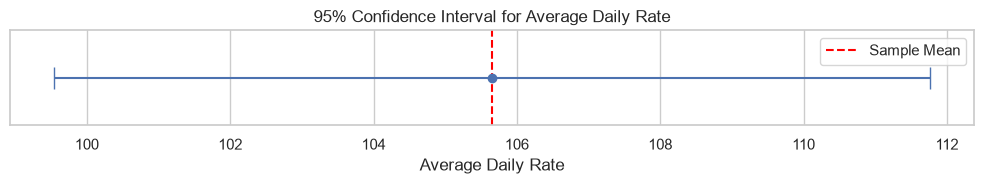

In [52]:
plt.figure(figsize=(10,2))

plt.errorbar(
    x=sample_mean,
    y=0,
    xerr=margin_of_error,
    fmt="o",
    capsize=8
)

plt.axvline(
    sample_mean,
    color="red",
    linestyle="--",
    label="Sample Mean"
)

plt.yticks([])

plt.xlabel("Average Daily Rate")

plt.title("95% Confidence Interval for Average Daily Rate")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/confidence_interval.png",
    dpi=300
)

plt.show()

### Compare Population Mean

In [53]:
population_mean = df["average_daily_rate"].mean()

comparison = pd.DataFrame({

    "Population Mean":[population_mean],

    "Sample Mean":[sample_mean],

    "CI Lower":[lower_bound],

    "CI Upper":[upper_bound]

})

comparison

,Population Mean,Sample Mean,CI Lower,CI Upper
0,105.524569,105.6529,99.539011,111.766789


## Business Interpretation

#### Based on a random sample of hotel bookings, we estimated the average daily room rate and calculated a 95% confidence interval. This interval represents a plausible range for the true average room rate across all bookings. Hotel managers can use this estimate to support pricing decisions while accounting for sampling uncertainty.

## Conclusion

#### A 95% confidence interval was constructed for the Average Daily Rate (ADR) using a random sample of hotel bookings. The interval provides a range of plausible values for the population mean while explicitly accounting for sampling variability. Confidence intervals offer more information than a single point estimate because they quantify the uncertainty associated with estimating population parameters from sample data.

# Population vs Sample

### Population Size

In [54]:
population_size = len(df)

print(f"Population Size : {population_size}")

Population Size : 87225


### Draw a Random Sample

In [55]:
sample_size = 500

sample_df = df.sample(
    n=sample_size,
    random_state=42
)

print(f"Sample Size : {len(sample_df)}")

Sample Size : 500


### Compare Population and Sample Means

In [56]:
population_mean = df["average_daily_rate"].mean()

sample_mean = sample_df["average_daily_rate"].mean()

comparison = pd.DataFrame({

    "Dataset":[
        "Population",
        "Sample"
    ],

    "Average Daily Rate":[
        population_mean,
        sample_mean
    ]

})

comparison

,Dataset,Average Daily Rate
0,Population,105.524569
1,Sample,105.433830


### Compare Standard Deviations

In [57]:
population_std = df["average_daily_rate"].std()

sample_std = sample_df["average_daily_rate"].std()

std_summary = pd.DataFrame({

    "Dataset":[
        "Population",
        "Sample"
    ],

    "Standard Deviation":[
        population_std,
        sample_std
    ]

})

std_summary

,Dataset,Standard Deviation
0,Population,49.032923
1,Sample,49.807829


### Compare Distributions

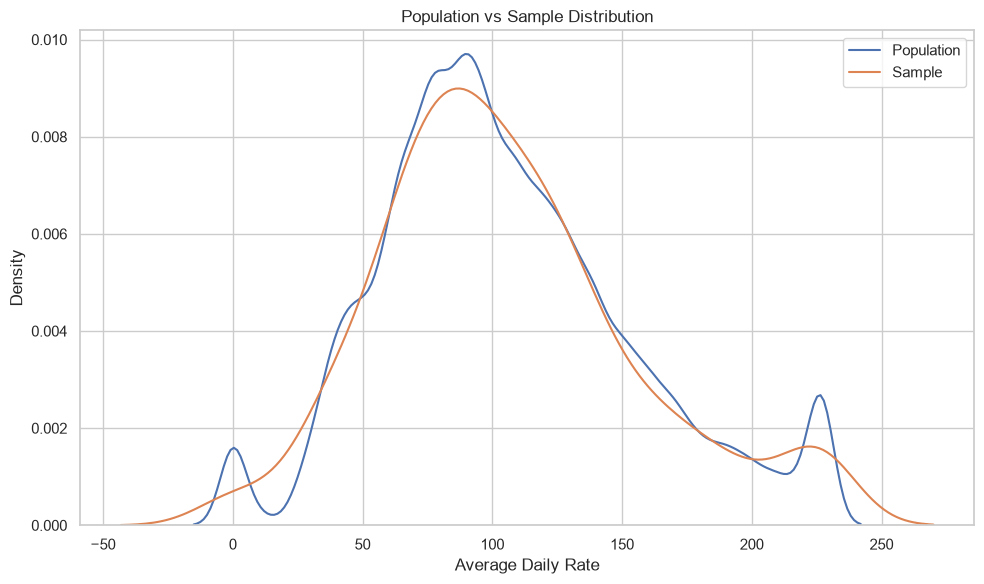

In [58]:
plt.figure(figsize=(10,6))

sns.kdeplot(
    df["average_daily_rate"],
    label="Population"
)

sns.kdeplot(
    sample_df["average_daily_rate"],
    label="Sample"
)

plt.title("Population vs Sample Distribution")

plt.xlabel("Average Daily Rate")

plt.ylabel("Density")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/population_vs_sample_distribution.png",
    dpi=300
)

plt.show()

### Population vs Sample Summary

In [59]:
summary = pd.DataFrame({

    "Metric":[
        "Population Size",
        "Sample Size",
        "Population Mean",
        "Sample Mean",
        "Population Std",
        "Sample Std"
    ],

    "Value":[
        population_size,
        sample_size,
        population_mean,
        sample_mean,
        population_std,
        sample_std
    ]

})

summary

,Metric,Value
0,Population Size,87225.000000
1,Sample Size,500.000000
2,Population Mean,105.524569
3,Sample Mean,105.433830
4,Population Std,49.032923
5,Sample Std,49.807829


## Business Interpretation

#### Hotel managers rarely have the opportunity to collect data from every possible future booking. By selecting a representative sample, they can estimate key metrics such as the Average Daily Rate (ADR) and make informed pricing and operational decisions. This analysis demonstrates that a well-chosen random sample can provide estimates that closely reflect the overall booking population.

## Conclusion

#### The processed hotel booking dataset was treated as the population, and a random sample of bookings was selected for comparison. The sample produced estimates of the Average Daily Rate and its variability that were close to those of the population, demonstrating how representative sampling supports reliable statistical inference. This concept forms the basis for estimation and hypothesis testing in subsequent analyses.

# Sampling Techniques

### Simple Random Sampling

In [60]:
simple_random_sample = df.sample(
    n=500,
    random_state=42
)

print(simple_random_sample.shape)

(500, 39)


In [61]:
# Average Daily Rate

simple_random_sample["average_daily_rate"].describe()

count    500.000000
mean     105.433830
std       49.807829
min        0.000000
25%       72.410000
50%       97.705000
75%      131.250000
max      226.875000
Name: average_daily_rate, dtype: float64

### Systematic Sampling

In [62]:
population_size = len(df)

sample_size = 500

k = population_size // sample_size

print("Sampling Interval:", k)

Sampling Interval: 174


In [63]:
# Create Sample

systematic_sample = df.iloc[::k].head(sample_size)

systematic_sample.shape

(500, 39)

In [64]:
# Statistics

systematic_sample["average_daily_rate"].describe()

count    500.000000
mean     105.655580
std       49.506376
min        0.000000
25%       69.997500
50%       99.000000
75%      132.375000
max      226.875000
Name: average_daily_rate, dtype: float64

### Stratified Sampling

In [65]:
df["hotel"]

0        Resort Hotel
1        Resort Hotel
2        Resort Hotel
3        Resort Hotel
4        Resort Hotel
             ...     
87220      City Hotel
87221      City Hotel
87222      City Hotel
87223      City Hotel
87224      City Hotel
Name: hotel, Length: 87225, dtype: str

In [66]:
# Check Distribution

df["hotel"].value_counts()

hotel
City Hotel      53270
Resort Hotel    33955
Name: count, dtype: int64

In [67]:
# Draw Stratified Sample

stratified_sample = (
    df
    .groupby("hotel", group_keys=False)
    .apply(
        lambda x: x.sample(
            frac=0.05,
            random_state=42
        )
    )
)

stratified_sample.shape

(4362, 38)

In [68]:
stratified_sample

,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,average_daily_rate,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,hotel_label,total_stay_duration,total_guests,lead_time_category,stay_type,booking_season,guest_status
34797,True,3,2015,August,34,20,0,2.0,2,0.0,0,BB,PRT,Direct,Direct,False,0,0,A,A,0,No Deposit,NaN,NaN,0,Transient,75.000,0,1,Canceled,2015-08-17,0,2.0,2.0,Short,Weekday,Summer,New
85222,False,296,2017,July,30,24,1,4.0,2,0.0,0,BB,PRT,Offline TA/TO,TA/TO,False,0,0,A,A,0,No Deposit,229.0,NaN,0,Transient-Party,103.600,0,1,Check-Out,2017-07-29,0,5.0,2.0,Very Long,Weekday,Summer,New
75704,False,3,2017,February,6,9,0,1.0,2,0.0,0,BB,PRT,Corporate,Corporate,False,0,0,A,A,0,No Deposit,NaN,243.0,0,Transient-Party,93.000,0,0,Check-Out,2017-02-10,0,1.0,2.0,Short,Weekday,Winter,New
82881,False,124,2017,June,24,11,2,5.0,2,0.0,0,BB,FRA,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,136.290,0,0,Check-Out,2017-06-18,0,7.0,2.0,Long,Weekday,Summer,New
65302,False,5,2016,July,29,14,0,3.0,2,0.0,0,SC,FRA,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,9.0,NaN,0,Transient,139.000,0,1,Check-Out,2016-07-17,0,3.0,2.0,Short,Weekday,Summer,New
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7822,True,167,2017,March,9,4,2,6.0,2,0.0,0,BB,GBR,Online TA,TA/TO,False,0,0,D,D,0,No Deposit,240.0,NaN,0,Transient,47.450,0,0,Canceled,2016-09-18,1,8.0,2.0,Long,Weekday,Spring,New
29509,False,75,2017,April,15,13,2,3.0,2,0.0,0,BB,LVA,Online TA,TA/TO,False,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,80.600,1,1,Check-Out,2017-04-18,1,5.0,2.0,Medium,Weekday,Spring,New
33660,False,200,2017,August,34,22,0,5.0,2,0.0,0,HB,ROU,Offline TA/TO,TA/TO,False,0,0,D,D,0,No Deposit,8.0,NaN,0,Transient,220.750,1,0,Check-Out,2017-08-27,1,5.0,2.0,Very Long,Weekday,Summer,New
5576,True,55,2016,August,33,8,1,4.0,2,0.0,0,BB,LUX,Online TA,TA/TO,False,0,0,G,G,0,No Deposit,240.0,NaN,0,Transient,226.875,0,0,Canceled,2016-06-14,1,5.0,2.0,Medium,Weekday,Summer,New


In [69]:
# Verify

stratified_sample["hotel_label"].value_counts()

hotel_label
0    2664
1    1698
Name: count, dtype: int64

## Cluster Sampling

In [70]:
# Select Cluster

np.random.seed(42)

selected_cluster = np.random.choice(
    df["hotel"].unique()
)

selected_cluster

'Resort Hotel'

In [71]:
# Cluster Sample

cluster_sample = df[
    df["hotel"] == selected_cluster
]

cluster_sample.shape

(33955, 39)

In [72]:
# Statistics

cluster_sample["average_daily_rate"].describe()

count    33955.000000
mean        97.260768
std         58.980739
min          0.000000
25%         51.500000
50%         79.500000
75%        134.100000
max        226.875000
Name: average_daily_rate, dtype: float64

## Compare Sample Sizes

In [73]:
sampling_summary = pd.DataFrame({

    "Technique":[
        "Simple Random",
        "Systematic",
        "Stratified",
        "Cluster"
    ],

    "Sample Size":[
        len(simple_random_sample),
        len(systematic_sample),
        len(stratified_sample),
        len(cluster_sample)
    ]

})

sampling_summary

,Technique,Sample Size
0,Simple Random,500
1,Systematic,500
2,Stratified,4362
3,Cluster,33955


## Compare Sample Means

In [74]:
comparison = pd.DataFrame({

    "Technique":[
        "Population",
        "Simple Random",
        "Systematic",
        "Stratified",
        "Cluster"
    ],

    "Average Daily Rate":[

        df["average_daily_rate"].mean(),

        simple_random_sample["average_daily_rate"].mean(),

        systematic_sample["average_daily_rate"].mean(),

        stratified_sample["average_daily_rate"].mean(),

        cluster_sample["average_daily_rate"].mean()

    ]

})

comparison

,Technique,Average Daily Rate
0,Population,105.524569
1,Simple Random,105.433830
2,Systematic,105.655580
3,Stratified,105.282354
4,Cluster,97.260768


## Visualization

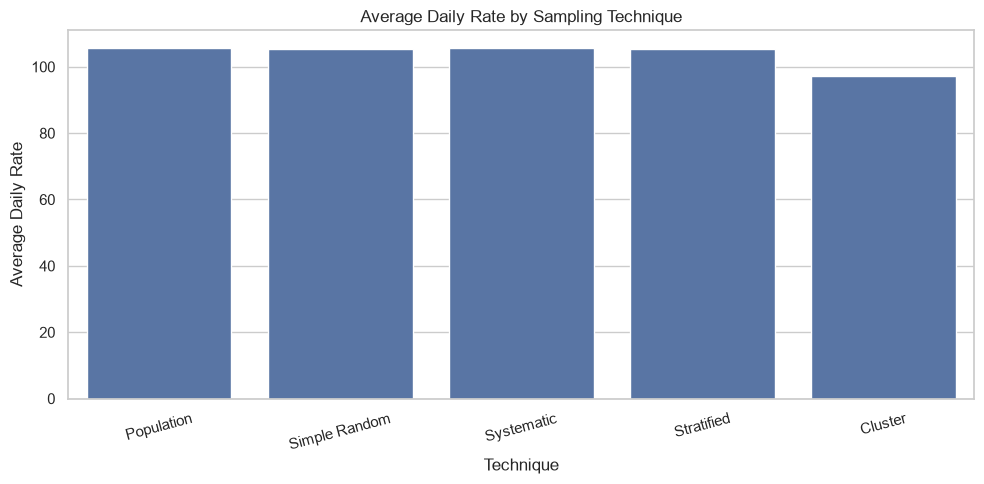

In [75]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison,
    x="Technique",
    y="Average Daily Rate"
)

plt.title("Average Daily Rate by Sampling Technique")

plt.xticks(rotation=15)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/sampling_techniques_comparison.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Different sampling techniques produce different estimates of the Average Daily Rate (ADR). Stratified sampling ensures that both City Hotels and Resort Hotels are represented proportionally, making it particularly useful when comparing hotel segments. Cluster sampling, while cost-effective in some real-world situations, may not fully represent the overall population if the selected cluster differs substantially from other groups.

## Conclusion

#### Four sampling techniques were applied to the hotel booking dataset and compared. Simple random and stratified sampling produced estimates that closely matched the population mean, while systematic sampling also performed well under the assumption of no hidden ordering in the data. Cluster sampling demonstrated how selecting a single group can influence estimates. Understanding these techniques is essential for selecting representative samples and ensuring valid statistical inference.

# Point Estimation

### Draw a Random Sample

In [76]:
sample_size = 500

sample = df.sample(
    n=sample_size,
    random_state=100
)

### Calculate Population Parameters

In [77]:
population_mean = df["average_daily_rate"].mean()

population_std = df["average_daily_rate"].std()

### Calculate Point Estimates

In [78]:
sample_mean = sample["average_daily_rate"].mean()

sample_std = sample["average_daily_rate"].std()

### Display Results

In [79]:
point_estimation = pd.DataFrame({

    "Parameter":[

        "Population Mean",

        "Sample Mean",

        "Population Std",

        "Sample Std"

    ],

    "Value":[

        population_mean,

        sample_mean,

        population_std,

        sample_std

    ]

})

point_estimation

,Parameter,Value
0,Population Mean,105.524569
1,Sample Mean,104.747340
2,Population Std,49.032923
3,Sample Std,50.171437


### Estimation Error

In [80]:
estimation_error = abs(
    sample_mean -
    population_mean
)

print(
    f"Estimation Error: {estimation_error:.4f}"
)

Estimation Error: 0.7772


### Relative Error

In [81]:
relative_error = (
    estimation_error /
    population_mean
) * 100

print(
    f"Relative Error: {relative_error:.2f}%"
)

Relative Error: 0.74%


### Visualization

In [82]:
comparison = pd.DataFrame({

    "Type":[
        "Population Mean",
        "Sample Mean"
    ],

    "ADR":[
        population_mean,
        sample_mean
    ]

})

comparison

,Type,ADR
0,Population Mean,105.524569
1,Sample Mean,104.747340


### Bar Chart

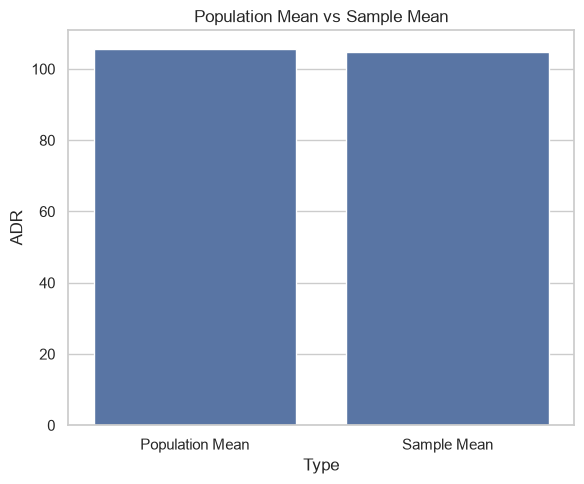

In [83]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Type",
    y="ADR"
)

plt.title("Population Mean vs Sample Mean")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/point_estimation.png",
    dpi=300
)

plt.show()

### Sample Size Effect

In [84]:
sample_sizes = [
    30,
    50,
    100,
    500,
    1000
]

results = []

for size in sample_sizes:

    sample = df.sample(
        n=size,
        random_state=42
    )

    sample_mean = sample[
        "average_daily_rate"
    ].mean()

    error = abs(
        sample_mean -
        population_mean
    )

    results.append({

        "Sample Size": size,

        "Sample Mean": sample_mean,

        "Absolute Error": error

    })

point_estimate_summary = pd.DataFrame(results)

point_estimate_summary

,Sample Size,Sample Mean,Absolute Error
0,30,92.484000,13.040569
1,50,91.507800,14.016769
2,100,95.986750,9.537819
3,500,105.433830,0.090739
4,1000,105.686075,0.161506


### Error vs Sample Size

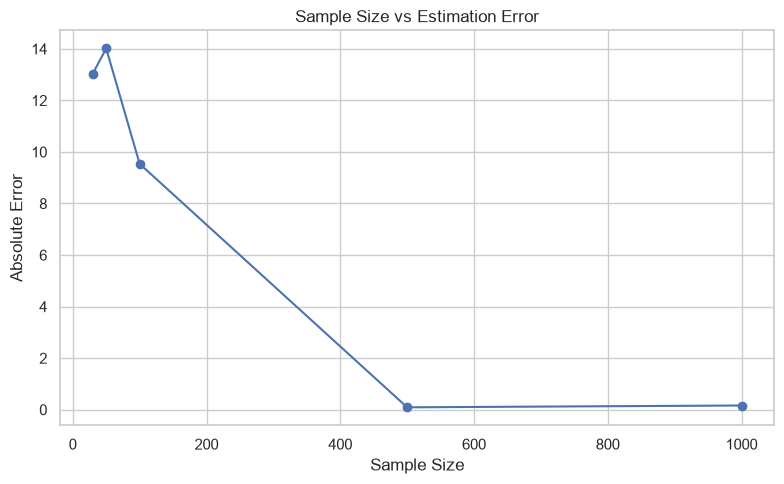

In [85]:
plt.figure(figsize=(8,5))

plt.plot(

    point_estimate_summary["Sample Size"],

    point_estimate_summary["Absolute Error"],

    marker="o"

)

plt.title(
    "Sample Size vs Estimation Error"
)

plt.xlabel("Sample Size")

plt.ylabel("Absolute Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/estimation_error.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Hotel managers often rely on sample data to estimate key performance metrics such as the Average Daily Rate (ADR). This analysis shows that the sample mean provides a practical estimate of the overall population mean. As the number of sampled bookings increases, the estimation error decreases, resulting in more reliable insights for pricing strategies, revenue forecasting, and operational planning.

## Conclusion

#### Point estimation was used to estimate the population mean and standard deviation of the Average Daily Rate (ADR) from randomly selected hotel bookings. The sample mean closely approximated the population mean, and estimation accuracy improved as the sample size increased. This demonstrates the importance of representative sampling and forms the basis for interval estimation and hypothesis testing.

# Confidence Level

### Draw a Sample

In [86]:
sample_size = 300

sample = df["average_daily_rate"].sample(
    n=sample_size,
    random_state=42
)

sample_mean = sample.mean()

sample_std = sample.std()

standard_error = sample_std / np.sqrt(sample_size)

### Define Confidence Levels

In [87]:
confidence_levels = [
    0.90,
    0.95,
    0.99
]

### Calculate Confidence Intervals

In [88]:
results = []

for confidence in confidence_levels:

    alpha = 1 - confidence

    z = stats.norm.ppf(1 - alpha / 2)

    margin_error = z * standard_error

    lower = sample_mean - margin_error

    upper = sample_mean + margin_error

    results.append({

        "Confidence Level": f"{int(confidence*100)}%",

        "Z-Score": round(z,3),

        "Margin of Error": round(margin_error,2),

        "Lower Bound": round(lower,2),

        "Upper Bound": round(upper,2)

    })

confidence_level_summary = pd.DataFrame(results)

confidence_level_summary

,Confidence Level,Z-Score,Margin of Error,Lower Bound,Upper Bound
0,90%,1.645,4.54,100.06,109.14
1,95%,1.960,5.41,99.20,110.01
2,99%,2.576,7.11,97.50,111.71


### Visualization

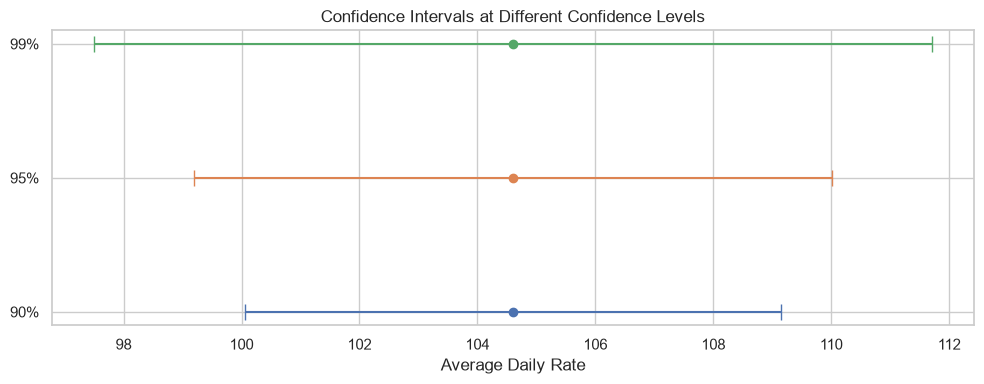

In [89]:
plt.figure(figsize=(10,4))

for i, row in confidence_level_summary.iterrows():

    plt.errorbar(

        x=(row["Lower Bound"] + row["Upper Bound"]) / 2,

        y=i,

        xerr=(row["Upper Bound"] - row["Lower Bound"]) / 2,

        fmt="o",

        capsize=6,

        label=row["Confidence Level"]

    )

plt.yticks(
    range(len(confidence_level_summary)),
    confidence_level_summary["Confidence Level"]
)

plt.xlabel("Average Daily Rate")

plt.title("Confidence Intervals at Different Confidence Levels")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/confidence_levels.png",
    dpi=300
)

plt.show()

### Compare Interval Width

In [90]:
confidence_level_summary["Interval Width"] = (

    confidence_level_summary["Upper Bound"] -

    confidence_level_summary["Lower Bound"]

)

confidence_level_summary

,Confidence Level,Z-Score,Margin of Error,Lower Bound,Upper Bound,Interval Width
0,90%,1.645,4.54,100.06,109.14,9.08
1,95%,1.960,5.41,99.20,110.01,10.81
2,99%,2.576,7.11,97.50,111.71,14.21


### Visualize Interval Width

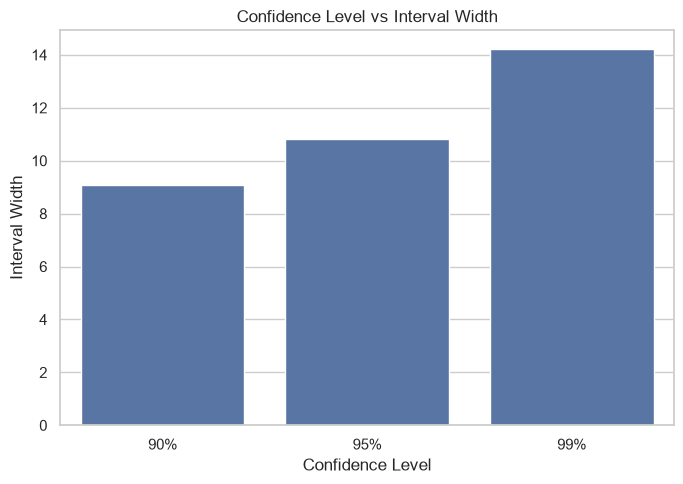

In [91]:
plt.figure(figsize=(7,5))

sns.barplot(

    data=confidence_level_summary,

    x="Confidence Level",

    y="Interval Width"

)

plt.title("Confidence Level vs Interval Width")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/confidence_interval_width.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### Confidence levels help hotel managers balance certainty and precision when estimating business metrics such as the Average Daily Rate (ADR). A 99% confidence level provides greater assurance that the interval contains the true average room rate, but it also produces a wider range of possible values. In practice, a 95% confidence level is commonly used because it offers a good balance between reliability and precision for business decision-making.

## Conclusion

#### Confidence intervals were calculated using 90%, 95%, and 99% confidence levels. The analysis demonstrated that increasing the confidence level results in a larger margin of error and a wider confidence interval. This illustrates the trade-off between confidence and precision and highlights why a 95% confidence level is widely adopted in statistical analysis and business reporting.

# Margin of Error

### Draw a Sample

In [92]:
sample_size = 300

sample = df["average_daily_rate"].sample(
    n=sample_size,
    random_state=42
)

sample_mean = sample.mean()
sample_std = sample.std()

print(f"Sample Mean: {sample_mean:.2f}")
print(f"Sample Standard Deviation: {sample_std:.2f}")

Sample Mean: 104.60
Sample Standard Deviation: 47.79


### Calculate Standard Error

In [93]:
standard_error = sample_std / np.sqrt(sample_size)

print(f"Standard Error: {standard_error:.4f}")

Standard Error: 2.7593


### Calculate Margin of Error (95%)

In [94]:
confidence_level = 0.95

alpha = 1 - confidence_level

z_score = stats.norm.ppf(1 - alpha / 2)

margin_of_error = z_score * standard_error

print(f"Margin of Error: {margin_of_error:.4f}")

Margin of Error: 5.4082


### Confidence Interval Using Margin of Error

In [95]:
lower = sample_mean - margin_of_error
upper = sample_mean + margin_of_error

print(f"95% Confidence Interval: ({lower:.2f}, {upper:.2f})")

95% Confidence Interval: (99.20, 110.01)


### Summary Table

In [96]:
margin_summary = pd.DataFrame({
    "Metric": [
        "Sample Size",
        "Sample Mean",
        "Standard Error",
        "Margin of Error",
        "Lower Bound",
        "Upper Bound"
    ],
    "Value": [
        sample_size,
        sample_mean,
        standard_error,
        margin_of_error,
        lower,
        upper
    ]
})

margin_summary

,Metric,Value
0,Sample Size,300.000000
1,Sample Mean,104.603433
2,Standard Error,2.759337
3,Margin of Error,5.408200
4,Lower Bound,99.195233
5,Upper Bound,110.011634


### Effect of Sample Size on Margin of Error

In [97]:
sample_sizes = [30, 50, 100, 300, 500, 1000]

results = []

for size in sample_sizes:

    sample = df["average_daily_rate"].sample(
        n=size,
        random_state=42
    )

    std = sample.std()

    se = std / np.sqrt(size)

    moe = z_score * se

    results.append({
        "Sample Size": size,
        "Margin of Error": moe
    })

moe_summary = pd.DataFrame(results)

moe_summary

,Sample Size,Margin of Error
0,30,12.810264
1,50,9.705905
2,100,7.836383
3,300,5.408200
4,500,4.365769
5,1000,3.133405


### Visualization

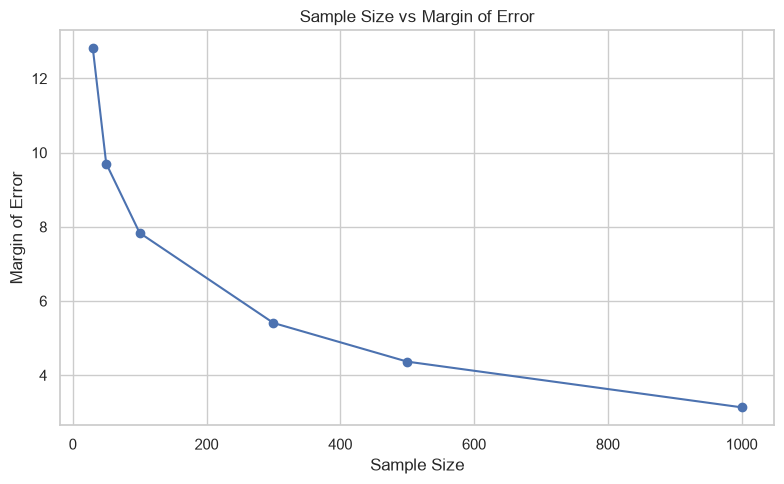

In [98]:
plt.figure(figsize=(8,5))

plt.plot(
    moe_summary["Sample Size"],
    moe_summary["Margin of Error"],
    marker="o"
)

plt.title("Sample Size vs Margin of Error")

plt.xlabel("Sample Size")

plt.ylabel("Margin of Error")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/margin_of_error_sample_size.png",
    dpi=300
)

plt.show()

### Effect of Confidence Level on Margin of Error

In [99]:
confidence_levels = [0.90, 0.95, 0.99]

results = []

for confidence in confidence_levels:

    alpha = 1 - confidence

    z = stats.norm.ppf(1 - alpha / 2)

    moe = z * standard_error

    results.append({
        "Confidence Level": f"{int(confidence*100)}%",
        "Margin of Error": moe
    })

confidence_moe = pd.DataFrame(results)

confidence_moe

,Confidence Level,Margin of Error
0,90%,4.538705
1,95%,5.408200
2,99%,7.107580


### Visualization

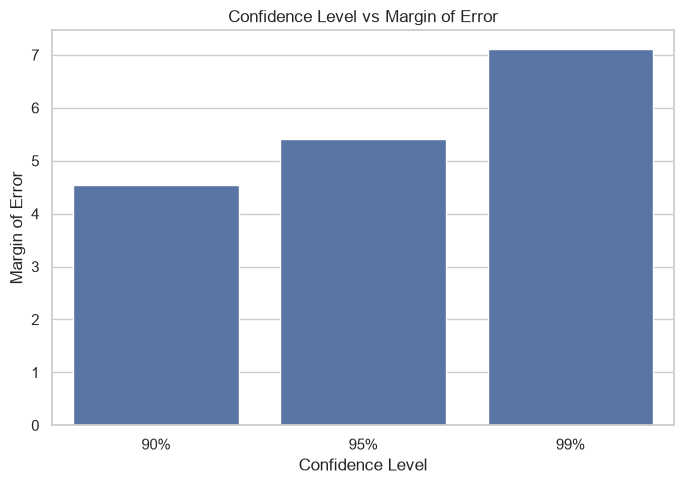

In [100]:
plt.figure(figsize=(7,5))

sns.barplot(
    data=confidence_moe,
    x="Confidence Level",
    y="Margin of Error"
)

plt.title("Confidence Level vs Margin of Error")

plt.tight_layout()

plt.savefig(
    "../figures/phase_03/margin_of_error_confidence.png",
    dpi=300
)

plt.show()

## Business Interpretation

#### The margin of error quantifies the uncertainty associated with estimating the Average Daily Rate (ADR) from a sample of hotel bookings. Larger sample sizes produce smaller margins of error, resulting in more precise estimates. Conversely, higher confidence levels require wider margins of error to provide greater assurance that the interval contains the true population value. Understanding these trade-offs helps hotel managers make informed, data-driven decisions while recognizing the uncertainty inherent in sample-based estimates.

## Conclusion

#### The margin of error was calculated for different sample sizes and confidence levels using the Average Daily Rate (ADR). The analysis demonstrated that increasing the sample size reduces the margin of error, while increasing the confidence level increases it. These results illustrate the balance between estimation precision and statistical confidence and complete the inferential statistics concepts required for subsequent assumption testing and hypothesis testing.